<a href="https://colab.research.google.com/github/dettystanly7676/Python_Practice_Repo/blob/main/Unsupervised_Casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score




In [ ]:
adult_data=pd.read_csv('/content/drive/MyDrive/DSA_ICT/Data/adult_dataset.csv')
adult_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [ ]:
adult_data.duplicated().sum()

np.int64(16)

In [ ]:
adult_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
adult_data.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [ ]:
adult_data.shape

(48842, 15)

In [ ]:
adult_data.size

732630

In [ ]:
adult_data.nunique()

,0
age,82
workclass,9
fnlwgt,28523
education,16
education-num,16
marital-status,7
occupation,15
relationship,6
race,5
sex,2


In [ ]:
adult_data.drop_duplicates(inplace=True)

In [ ]:
adult_data.duplicated().sum()

np.int64(0)

In [ ]:
adult_data.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


Handling missing values

In [ ]:
adult_data['age']=adult_data['age'].fillna(adult_data['age'].median())
adult_data['hours-per-week']=adult_data['hours-per-week'].fillna(adult_data['hours-per-week'].median())

adult_data['workclass']=adult_data['workclass'].fillna(adult_data['workclass'].mode()[0])
adult_data['occupation']=adult_data['occupation'].fillna(adult_data['occupation'].mode()[0])
adult_data['native-country']=adult_data['native-country'].fillna(adult_data['native-country'].mode()[0])


In [ ]:
adult_data[adult_data.isin(['?']).any(axis=1)].index

Index([   14,    27,    38,    51,    61,    69,    77,    93,   106,   128,
       ...
       32490, 32492, 32494, 32510, 32525, 32530, 32531, 32539, 32541, 32542],
      dtype='int64', length=2374)

In [ ]:
adult_data.replace('?', np.nan, inplace=True)
adult_data[adult_data.isnull().any(axis=1)]
for col in adult_data.select_dtypes(include='object'):
    adult_data[col].fillna(adult_data[col].mode()[0], inplace=True)

for col in adult_data.select_dtypes(include='int64'):
    adult_data[col].fillna(adult_data[col].median(), inplace=True)

/tmp/ipykernel_5194/319427616.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  adult_data[col].fillna(adult_data[col].mode()[0], inplace=True)
/tmp/ipykernel_5194/319427616.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
adult_data[adult_data.isin(['?']).any(axis=1)].index

Index([], dtype='int64')

In [ ]:
adult_data.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Outlier detection

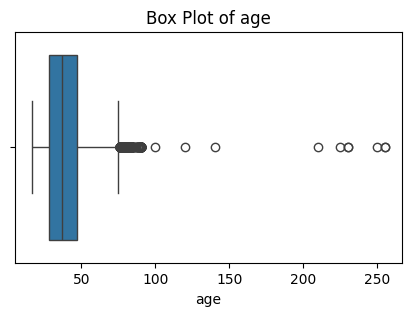

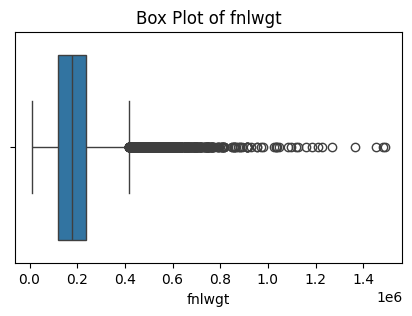

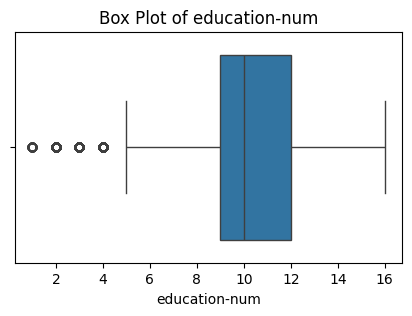

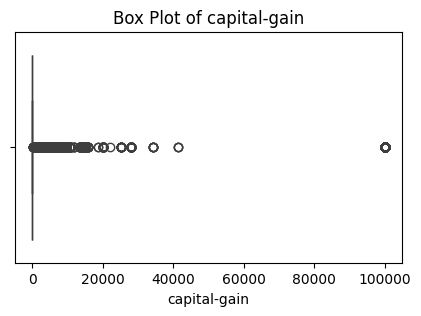

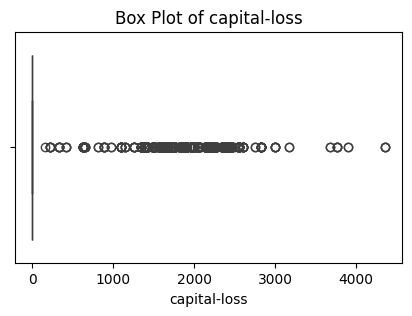

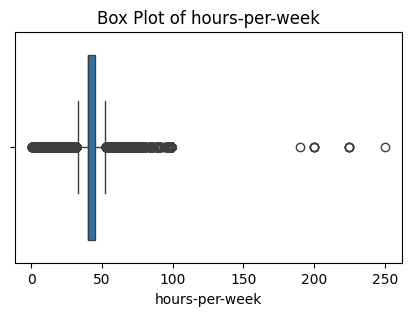

{'age': 363,
 'fnlwgt': 1453,
 'education-num': 1792,
 'capital-gain': 4035,
 'capital-loss': 2282,
 'hours-per-week': 12833}

In [ ]:
num_cols = adult_data.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in num_cols:
    Q1 = adult_data[col].quantile(0.25)
    Q3 = adult_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = adult_data[
        (adult_data[col] < lower_bound) | (adult_data[col] > upper_bound)
    ]
    outlier_summary[col] = outliers.shape[0]

    plt.figure(figsize=(5, 3))
    sns.boxplot(x=adult_data[col])
    plt.title(f'Box Plot of {col}')
    plt.show()


outlier_summary

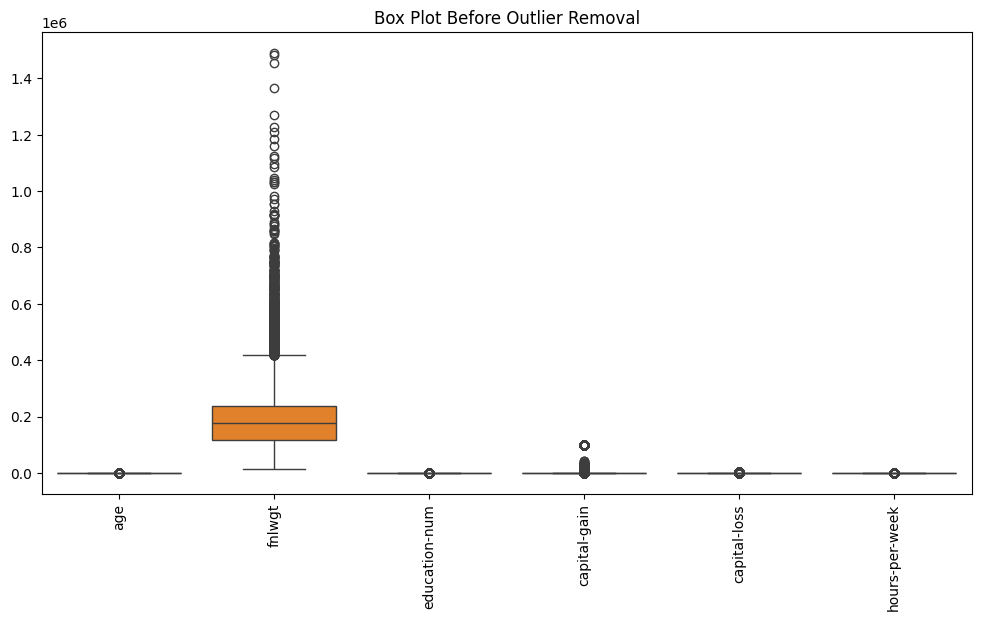

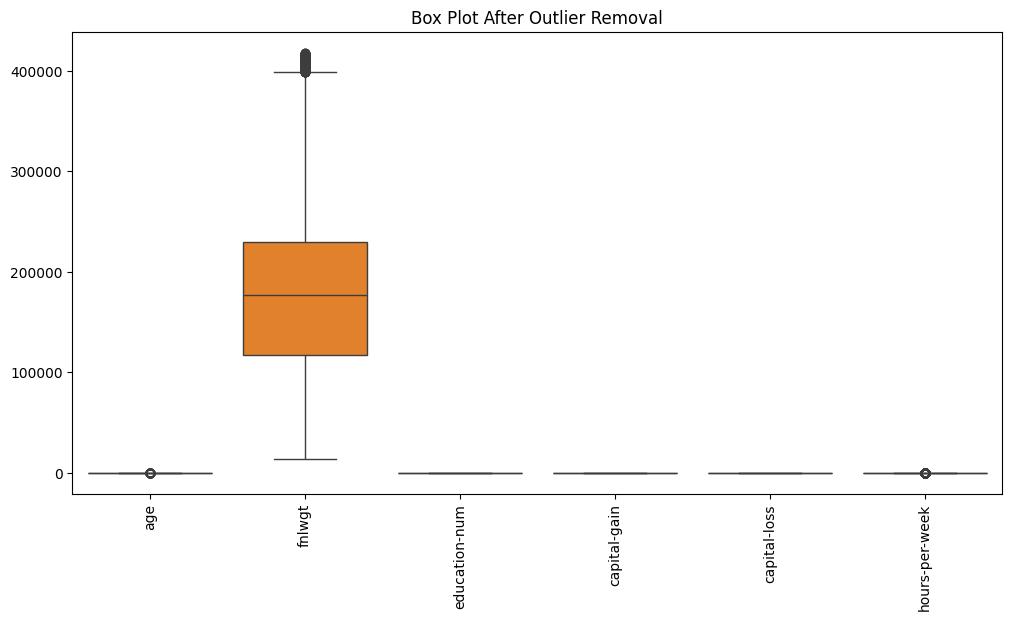

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
5,37.0,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,<=50K
7,52.0,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45.0,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48835,48.0,Local-gov,349230,Masters,14,Divorced,Other-service,Not-in-family,White,Male,0,0,40.0,United-States,<=50K.
48836,33.0,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40.0,United-States,<=50K.
48837,39.0,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36.0,United-States,<=50K.
48838,64.0,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40.0,United-States,<=50K.


In [ ]:
num_cols = adult_data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 6))
sns.boxplot(data=adult_data[num_cols])
plt.xticks(rotation=90)
plt.title("Box Plot Before Outlier Removal")
plt.show()


outlier_rows = adult_data.copy()

for col in num_cols:
    Q1 = adult_data[col].quantile(0.25)
    Q3 = adult_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_rows = outlier_rows[
        (outlier_rows[col] >= lower) & (outlier_rows[col] <= upper)
    ]

plt.figure(figsize=(12, 6))
sns.boxplot(data=outlier_rows[num_cols])
plt.xticks(rotation=90)
plt.title("Box Plot After Outlier Removal")
plt.show()


outlier_rows


Encoding

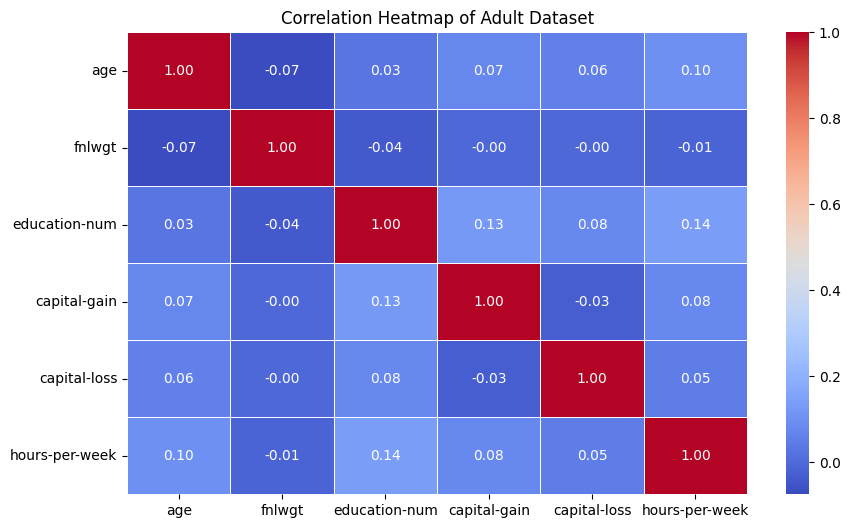

In [ ]:
num_cols = adult_data.select_dtypes(include=['int64', 'float64'])

corr_matrix = num_cols.corr()
corr_matrix

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Adult Dataset")
plt.show()


In [ ]:
cat_cols = adult_data.select_dtypes(include='object').columns
cat_cols

adult_data = pd.get_dummies(
    adult_data,
    columns=cat_cols,
    drop_first=True
)

adult_data.head()


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,...,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,income_<=50K.,income_>50K,income_>50K.
0,39.0,77516,13,2174,0,40.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,50.0,83311,13,0,0,13.0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,38.0,215646,9,0,0,40.0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
3,53.0,234721,7,0,0,40.0,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,28.0,338409,13,0,0,40.0,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


Scaling

In [ ]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(adult_data)
data_scaled


array([[ 0.02959544, -1.06196015,  1.13653268, ..., -0.58439802,
        -0.43739444, -0.29241181],
       [ 0.83826953, -1.00708397,  1.13653268, ..., -0.58439802,
        -0.43739444, -0.29241181],
       [-0.04392038,  0.24607193, -0.41944379, ..., -0.58439802,
        -0.43739444, -0.29241181],
       ...,
       [-0.04392038,  1.75492524,  1.13653268, ...,  1.71116254,
        -0.43739444, -0.29241181],
       [ 0.39717457, -1.00159162,  1.13653268, ...,  1.71116254,
        -0.43739444, -0.29241181],
       [-0.26446786, -0.07113982,  1.13653268, ..., -0.58439802,
        -0.43739444,  3.41983447]])

In [ ]:
# Assuming 'income' is the target column
X = adult_data.drop('income', axis=1, errors='ignore')


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

imputer = SimpleImputer(strategy='mean')
X_scaled = imputer.fit_transform(X_scaled)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)


(48826, 100)


In [ ]:
explained_variance = pca.explained_variance_ratio_
explained_variance


array([3.74975405e-02, 2.67732497e-02, 2.51123035e-02, 2.04470298e-02,
       1.82692835e-02, 1.73110571e-02, 1.57111878e-02, 1.51237463e-02,
       1.41209856e-02, 1.34012960e-02, 1.29221842e-02, 1.25868524e-02,
       1.22368763e-02, 1.19666942e-02, 1.17463874e-02, 1.16436510e-02,
       1.14907747e-02, 1.13375059e-02, 1.13096894e-02, 1.11965654e-02,
       1.11152903e-02, 1.09629265e-02, 1.08650963e-02, 1.07757163e-02,
       1.07180953e-02, 1.06582578e-02, 1.06300553e-02, 1.06037825e-02,
       1.05009955e-02, 1.04803900e-02, 1.04360719e-02, 1.04083867e-02,
       1.03193991e-02, 1.02689884e-02, 1.02438711e-02, 1.02246954e-02,
       1.01846479e-02, 1.01423078e-02, 1.00901222e-02, 1.00698251e-02,
       1.00498140e-02, 1.00407236e-02, 1.00337329e-02, 1.00231815e-02,
       1.00173236e-02, 1.00164413e-02, 1.00113059e-02, 1.00081803e-02,
       1.00077767e-02, 1.00043243e-02, 1.00018614e-02, 9.99501059e-03,
       9.99113303e-03, 9.98045928e-03, 9.97612882e-03, 9.95971095e-03,
      

In [ ]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)


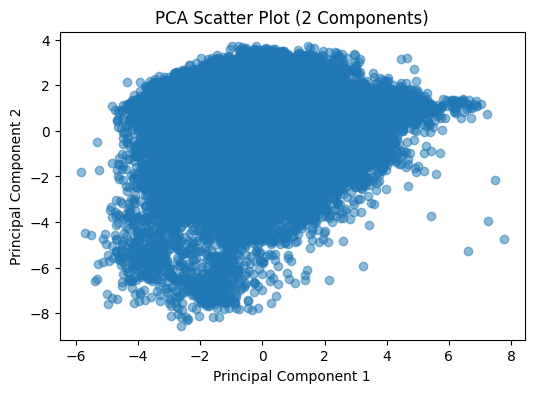

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Scatter Plot (2 Components)')
plt.show()


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
import numpy as np

imputer = SimpleImputer(strategy='mean')
data_scaled = imputer.fit_transform(data_scaled)


pca = PCA(n_components=0.90)
data_pca = pca.fit_transform(data_scaled)

print(data_pca.shape)

(48826, 78)


Clustering

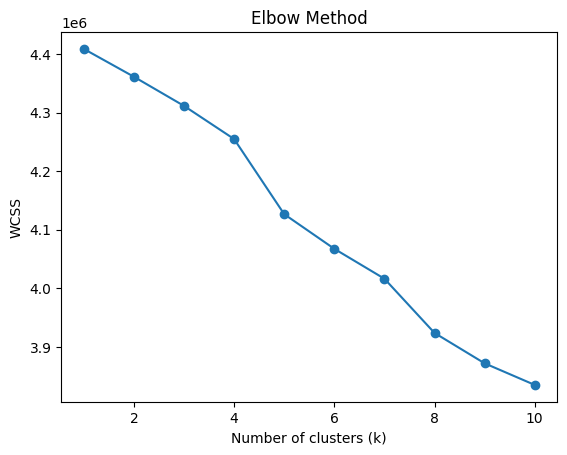

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_pca)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.3f}")


best_k = max(scores, key=scores.get)
print("silhouette:", best_k)

k=2, silhouette score=0.685


In [ ]:
best_k = 2

kmeans = KMeans(n_clusters=best_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
labels = kmeans.fit_predict(data_pca)


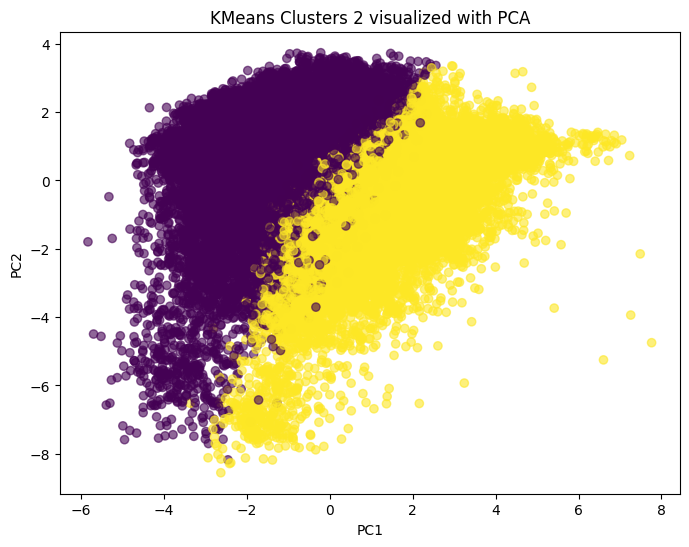

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data_pca[:,0], data_pca[:,1], c=labels, cmap='viridis', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters {best_k} visualized with PCA")
plt.show()

Agglomerative

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

mergings = linkage(X, method='ward')
plt.figure(figsize=(10,6))
dendrogram(mergings, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

NameError: name 'X' is not defined

In [ ]:
from sklearn.cluster import AgglomerativeClustering
for i in range(2,11):
   hc = AgglomerativeClustering(n_clusters= i,linkage= 'ward')
   hc_lables = hc.fit_predict(X_scaled)
   sil_score = silhouette_score(X_scaled,hc_lables)
   print('silhouette score for k = {} is {}'.format(i,sil_score))

In [ ]:
hc = AgglomerativeClustering(n_clusters= 5,linkage= 'ward')
hc_labels = hc.fit_predict(X_scaled)
adult_data['hc_clusters'] = hc_labels
adult_data.head()

In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=k)
agg_labels = agg.fit_predict(data_pca)

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    data_pca[:, 0],
    data_pca[:, 1],
    c=agg_labels,
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglomerative Clusters visualized with PCA")
plt.show()
